# Naive RAG

이번 튜토리얼에서는 LangGraph를 사용하여 가장 기본적인 RAG(Retrieval-Augmented Generation) 파이프라인을 구축합니다.

**학습 목표**

- PDF 문서를 기반으로 Retriever와 Chain을 생성하는 방법을 학습합니다.
- LangGraph의 State, Node, Edge를 활용하여 RAG 워크플로우를 구성합니다.
- 그래프를 실행하고 스트리밍 출력하는 방법을 익힙니다.

![langgraph-naive-rag](assets/langgraph-naive-rag.png)

> 참고 문서: [Build a custom RAG agent with LangGraph](https://docs.langchain.com/oss/python/langgraph/agentic-rag.md)

## 환경 설정

먼저 필요한 환경 변수를 로드하고 LangSmith 추적을 설정합니다.

아래 코드에서는 환경 변수와 LangSmith 추적을 설정합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다.
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-RAG")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-RAG


## PDF 기반 Retrieval Chain 생성

PDF 문서를 기반으로 Retrieval Chain을 생성합니다. LangGraph에서는 Retriever와 Chain을 분리하여 각 노드에서 세부 처리를 수행할 수 있습니다.
Retriever는 질문에 관련된 문서를 검색하고, Chain은 검색된 문서를 기반으로 LLM에게 답변을 요청하는 역할을 합니다.

**사용 문서**

- 소프트웨어정책연구소(SPRi) - 2023년 12월호
- 파일명: `SPRI_AI_Brief_2023년12월호_F.pdf`

아래 코드에서는 PDF 문서를 로드하여 Retriever와 Chain 객체를 생성합니다.

In [3]:
from rag.pdf import PDFRetrievalChain

# PDF 문서를 로드합니다.
pdf = PDFRetrievalChain(["data/SPRI_AI_Brief_2023년12월호_F.pdf"]).create_chain()

# retriever와 chain을 생성합니다.
pdf_retriever = pdf.retriever
pdf_chain = pdf.chain

Cache configured for multi-PDF processing
Loading PDF: data/SPRI_AI_Brief_2023년12월호_F.pdf
Successfully loaded 23 pages from: data/SPRI_AI_Brief_2023년12월호_F.pdf

Loading Summary:
- Successfully loaded: 1 files
- Failed to load: 0 files
- Total documents loaded: 23
FAISS index saved to cache


### Retriever 테스트

`pdf_retriever`를 사용하여 검색 결과를 가져옵니다.
Retriever는 사용자 질문과 관련된 문서 조각(chunk)을 벡터 유사도 기반으로 검색합니다.

아래 코드에서는 예시 질문으로 Retriever를 호출하여 검색 결과를 확인합니다.

In [4]:
# 검색 테스트
search_result = pdf_retriever.invoke("앤스로픽에 투자한 기업과 투자금액을 알려주세요.")
search_result

[Document(id='a805e214-f93d-416b-9abd-6185094b2cfa', metadata={'source': 'data/SPRI_AI_Brief_2023년12월호_F.pdf', 'file_path': 'data/SPRI_AI_Brief_2023년12월호_F.pdf', 'page': 13, 'total_pages': 23, 'Author': 'dj', 'Creator': 'Hwp 2018 10.0.0.13462', 'Producer': 'Hancom PDF 1.3.0.542', 'CreationDate': "D:20231208132838+09'00'", 'ModDate': "D:20231208132838+09'00'", 'PDFVersion': '1.4'}, page_content='1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n구글, 앤스로픽에 20억 달러 투자로 생성 AI 협력 강화\nKEY Contents\nn 구글이 앤스로픽에 최대 20억 달러 투자에 합의하고 5억 달러를 우선 투자했으며, 앤스로픽은\n구글과 클라우드 서비스 사용 계약도 체결\nn 3대 클라우드 사업자인 구글, 마이크로소프트, 아마존은 차세대 AI 모델의 대표 기업인\n앤스로픽 및 오픈AI와 협력을 확대하는 추세\n£구글, 앤스로픽에 최대 20억 달러 투자 합의 및 클라우드 서비스 제공\nn 구글이 2023년 10월 27일 앤스로픽에 최대 20억 달러를 투자하기로 합의했으며, 이 중 5억\n달러를 우선 투자하고 향후 15억 달러를 추가로 투자할 방침\n∙ 구글은 2023년 2월 앤스로픽에 이미 5억 5,000만 달러를 투자한 바 있으며, 아마존도 지난 9월\n앤스로픽에 최대 40억 달러의 투자 계획을 공개\n∙ 한편, 2023년 11월 8일 블룸버그 보도에 따르면 앤스로픽은 구글의 클라우드 서비스 사용을 위해\n4년간 30억 달러 규모의 계약을 체결\n∙ 오픈AI 창업자 그룹의 일원이었던 다리오(Dario Amodei)와 다니엘라 아모데이(Dani

### Chain 테스트

검색된 문서를 Chain의 context로 전달하여 답변을 생성합니다.
Chain은 검색된 문서와 질문을 LLM에 함께 전달하여 근거 기반의 답변을 생성합니다.

아래 코드에서는 검색 결과를 context로 전달하고 답변을 생성합니다.

In [5]:
# 검색 결과를 기반으로 답변을 생성합니다.
answer = pdf_chain.invoke(
    {
        "question": "앤스로픽에 투자한 기업과 투자금액을 알려주세요.",
        "context": search_result
    }
)
print(answer)

앤스로픽에 투자한 기업과 투자금액은 다음과 같습니다.

- 구글: 최대 20억 달러 투자 합의, 이 중 5억 달러를 우선 투자했으며 2023년 2월에 이미 5억 5,000만 달러 투자  
- 아마존: 최대 40억 달러 투자 계획 공개

또한, 앤스로픽은 구글과 4년간 30억 달러 규모의 클라우드 서비스 사용 계약을 체결했습니다.

**Source**  
- data/SPRI_AI_Brief_2023년12월호_F.pdf (page 13)


## State 정의

`State`는 그래프의 노드 간에 공유되는 상태를 정의합니다.
각 노드는 State를 입력으로 받아 처리 후 업데이트된 State를 반환하며, 이를 통해 노드 간 데이터 전달이 이루어집니다.

`TypedDict`, `dataclass`, `Pydantic BaseModel`을 State 스키마로 사용할 수 있습니다. 이 중 `TypedDict`가 가장 경량하고 권장되는 방식입니다. `Annotated` 타입을 사용하여 리듀서 함수를 지정할 수 있습니다.

아래 코드에서는 RAG 파이프라인에 필요한 질문, 검색 문서, 답변, 대화 히스토리를 포함하는 State를 정의합니다.

In [6]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages


# GraphState 상태 정의 (TypedDict 기반 - LangGraph v1 호환)
class GraphState(TypedDict):
    question: Annotated[str, "Question"]  # 사용자 질문
    context: Annotated[str, "Context"]  # 검색된 문서
    answer: Annotated[str, "Answer"]  # 생성된 답변
    messages: Annotated[list, add_messages]  # 대화 히스토리 (누적)

## 노드(Node) 정의

노드는 각 단계를 처리하는 함수입니다. State를 입력으로 받아 처리 후 업데이트된 State를 반환합니다.
각 노드 함수는 필요한 값을 State에서 읽고, 처리 결과를 딕셔너리 형태로 반환하여 State를 업데이트합니다.

**노드 목록**

- `retrieve_document`: 문서를 검색합니다.
- `llm_answer`: 검색된 문서를 기반으로 답변을 생성합니다.

아래 코드에서는 문서 검색 노드와 답변 생성 노드를 각각 정의합니다.

In [7]:
from langchain_teddynote.messages import messages_to_history
from rag.utils import format_docs


def retrieve_document(state: GraphState) -> GraphState:
    """문서를 검색하는 노드입니다.
    
    사용자 질문을 기반으로 관련 문서를 검색하고 포맷팅합니다.
    """
    # 질문을 상태에서 가져옵니다.
    latest_question = state["question"]

    # 문서에서 검색하여 관련성 있는 문서를 찾습니다.
    retrieved_docs = pdf_retriever.invoke(latest_question)

    # 검색된 문서를 형식화합니다. (프롬프트 입력용)
    retrieved_docs = format_docs(retrieved_docs)

    # 검색된 문서를 context 키에 저장합니다.
    return {"context": retrieved_docs}


def llm_answer(state: GraphState) -> GraphState:
    """답변을 생성하는 노드입니다.
    
    검색된 문서와 대화 기록을 기반으로 답변을 생성합니다.
    """
    # 질문을 상태에서 가져옵니다.
    latest_question = state["question"]

    # 검색된 문서를 상태에서 가져옵니다.
    context = state["context"]

    # 체인을 호출하여 답변을 생성합니다.
    response = pdf_chain.invoke(
        {
            "question": latest_question,
            "context": context,
            "chat_history": messages_to_history(state["messages"]),
        }
    )
    
    # 생성된 답변과 메시지를 상태에 저장합니다.
    return {
        "answer": response,
        "messages": [("user", latest_question), ("assistant", response)],
    }

## 그래프 생성

노드를 추가하고 엣지로 연결하여 그래프를 생성합니다.
`StateGraph`에 노드를 등록한 후 엣지로 실행 순서를 정의하고, `compile()` 메서드를 호출하여 실행 가능한 형태로 변환합니다.

**엣지 종류**

- **일반 엣지**: 항상 다음 노드로 이동합니다.
- **조건부 엣지**: 조건에 따라 다음 노드를 결정합니다.

아래 코드에서는 노드를 추가하고 엣지를 연결한 후 그래프를 컴파일합니다.

In [8]:
from langgraph.graph import END, START, StateGraph
from langgraph.checkpoint.memory import MemorySaver

# 그래프 생성
workflow = StateGraph(GraphState)

# 노드 정의
workflow.add_node("retrieve", retrieve_document)
workflow.add_node("llm_answer", llm_answer)

# 엣지 정의
workflow.add_edge(START, "retrieve")  # 시작점에서 retrieve 노드로 연결
workflow.add_edge("retrieve", "llm_answer")  # 검색 -> 답변
workflow.add_edge("llm_answer", END)  # 답변 -> 종료

# 체크포인터 설정 (대화 기록 저장)
memory = MemorySaver()

# 그래프 컴파일
app = workflow.compile(checkpointer=memory)

### 그래프 시각화

컴파일한 그래프를 시각화합니다.
그래프를 시각화하면 노드 간 연결 구조와 실행 흐름을 직관적으로 확인할 수 있습니다.

아래 코드에서는 `visualize_graph` 함수를 사용하여 그래프 구조를 시각적으로 표시합니다.

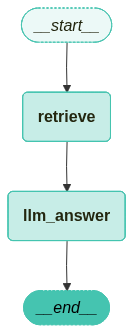

In [9]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(app)

## 그래프 실행

그래프를 실행하여 RAG 파이프라인을 동작시킵니다.
`invoke`는 전체 결과를 한 번에 반환하고, `stream`은 각 노드의 출력을 순차적으로 반환합니다.

**주요 파라미터**

- `config`: 그래프 실행 시 필요한 설정 정보를 전달합니다.
- `recursion_limit`: 그래프 실행 시 재귀 최대 횟수를 설정합니다.
- `inputs`: 그래프 실행에 필요한 입력 데이터입니다.

> 참고 문서: [LangGraph Streaming](https://docs.langchain.com/oss/python/langgraph/streaming.md)

아래 코드에서는 일반 모드와 스트리밍 모드로 그래프를 실행합니다.

In [10]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import invoke_graph, stream_graph, random_uuid

# config 설정 (재귀 최대 횟수, thread_id)
config = RunnableConfig(recursion_limit=20, configurable={"thread_id": random_uuid()})

# 질문 입력
inputs = GraphState(question="앤스로픽에 투자한 기업과 투자금액을 알려주세요.")

# 그래프 실행 (일반 모드)
invoke_graph(app, inputs, config)


🔄 Node: retrieve 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
context:
<document><content>1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육
구글, 앤스로픽에 20억 달러 투자로 생성 AI 협력 강화
KEY Contents
n 구글이 앤스로픽에 최대 20억 달러 투자에 합의하고 5억 달러를 우선 투자했으며, 앤스로픽은
구글과 클라우드 서비스 사용 계약도 체결
n 3대 클라우드 사업자인 구글, 마이크로소프트, 아마존은 차세대 AI 모델의 대표 기업인
앤스로픽 및 오픈AI와 협력을 확대하는 추세
£구글, 앤스로픽에 최대 20억 달러 투자 합의 및 클라우드 서비스 제공
n 구글이 2023년 10월 27일 앤스로픽에 최대 20억 달러를 투자하기로 합의했으며, 이 중 5억
달러를 우선 투자하고 향후 15억 달러를 추가로 투자할 방침
∙ 구글은 2023년 2월 앤스로픽에 이미 5억 5,000만 달러를 투자한 바 있으며, 아마존도 지난 9월
앤스로픽에 최대 40억 달러의 투자 계획을 공개
∙ 한편, 2023년 11월 8일 블룸버그 보도에 따르면 앤스로픽은 구글의 클라우드 서비스 사용을 위해
4년간 30억 달러 규모의 계약을 체결
∙ 오픈AI 창업자 그룹의 일원이었던 다리오(Dario Amodei)와 다니엘라 아모데이(Daniela Amodei)
남매가 2021년 설립한 앤스로픽은 챗GPT의 대항마 ‘클로드(Claude)’ LLM을 개발
n 아마존과 구글의 앤스로픽 투자에 앞서, 마이크로소프트는 차세대 AI 모델의 대표 주자인 오픈
AI와 협력을 확대
∙ 마이크로소프트는 오픈AI에 앞서 투자한 30억 달러에 더해 2023년 1월 추가로 100억 달러를
투자하기로 하면서 오픈AI의 지분 49%를 확보했으며, 오픈AI는 마이크로소프트의 애저(Azure)
클라우드 플랫폼을 사용해 AI 모델을 훈련
£구글, 클라우드 경쟁력 강화를 위해 생성 AI 투자 확대
n 구글은 수익률이 높은 

In [11]:
# 그래프 실행 (스트리밍 모드)
stream_graph(app, inputs, config)


🔄 Node: llm_answer 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
앤스로픽에 투자한 기업과 투자금액은 다음과 같습니다.

- 구글: 최대 20억 달러 투자 합의 (2023년 10월 27일), 이 중 5억 달러 우선 투자, 2023년 2월에 이미 5억 5,000만 달러 투자
- 아마존: 최대 40억 달러 투자 계획 공개 (2023년 9월)

또한, 앤스로픽은 구글과 4년간 30억 달러 규모의 클라우드 서비스 계약을 체결했습니다.

**Source**
- data/SPRI_AI_Brief_2023년12월호_F.pdf (p.14)

### 결과 확인

그래프 실행 후 최종 상태를 확인합니다.
`get_state()` 메서드를 사용하면 현재 스레드의 최종 상태를 조회할 수 있습니다.

아래 코드에서는 그래프 실행이 완료된 후의 질문과 답변을 출력합니다.

In [12]:
# 최종 상태 조회
outputs = app.get_state(config).values

print(f'Question: {outputs["question"]}')
print("===" * 20)
print(f'Answer:\n{outputs["answer"]}')

Question: 앤스로픽에 투자한 기업과 투자금액을 알려주세요.
Answer:
앤스로픽에 투자한 기업과 투자금액은 다음과 같습니다.

- 구글: 최대 20억 달러 투자 합의 (2023년 10월 27일), 이 중 5억 달러 우선 투자, 2023년 2월에 이미 5억 5,000만 달러 투자
- 아마존: 최대 40억 달러 투자 계획 공개 (2023년 9월)

또한, 앤스로픽은 구글과 4년간 30억 달러 규모의 클라우드 서비스 계약을 체결했습니다.

**Source**
- data/SPRI_AI_Brief_2023년12월호_F.pdf (p.14)


## 정리

이 튜토리얼에서는 LangGraph를 사용하여 기본적인 Naive RAG 파이프라인을 구축했습니다.

### 핵심 개념

1. **State**: `TypedDict` 기반으로 노드 간 공유 상태를 정의합니다.
2. **Node**: 각 단계의 처리 로직을 함수로 구현합니다.
3. **Edge**: 노드 간의 흐름을 정의합니다.
4. **Checkpointer**: 대화 기록을 저장하여 멀티턴 대화를 지원합니다.

### 다음 단계

다음 튜토리얼에서는 검색된 문서에 대한 **관련성 체크(Groundedness Check)**를 추가하여 RAG 파이프라인의 품질을 향상시키는 방법을 학습합니다.